
#VendorPerformance Analysis
### Data Analysis Project using Python & Pands

## Project Objective

The objective of this project is to analyze vendor purchasing and sales data to evaluate vendor performance, profitability, sales contribution, and purchasing efficiency.

The analysis aims to identify important vendor-level patterns and generate data-driven insights that can support better purchasing and inventory decisions.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Data Preparation

The datasets were loaded into Python using Pandas and inspected for:

- Number of rows and columns
- Column names and data types
- Missing values
- Vendor information
- Sales and purchase values
- Quantity-related fields

The data was then prepared for vendor-level sales, purchasing, profitability, and inventory analysis.

In [1]:
import pandas as pd
sales=pd.read_csv("sales.csv")
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [2]:
sales.shape

(12825363, 14)

In [3]:
sales.columns


Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='str')

In [4]:
sales.isnull().sum()


InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

In [5]:
sales.dtypes


InventoryId           str
Store               int64
Brand               int64
Description           str
Size                  str
SalesQuantity       int64
SalesDollars      float64
SalesPrice        float64
SalesDate             str
Volume            float64
Classification      int64
ExciseTax         float64
VendorNo            int64
VendorName            str
dtype: object

In [6]:
sales.describe()

,Store,Brand,SalesQuantity,SalesDollars,SalesPrice,Volume,Classification,ExciseTax,VendorNo
count,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07,1.282536e+07
mean,4.389572e+01,1.215460e+04,2.566623e+00,3.524758e+01,1.569027e+01,9.394389e+02,1.413892e+00,1.479431e+00,7.125907e+03
std,2.353947e+01,1.236843e+04,4.551810e+00,8.835689e+01,1.512728e+01,6.993202e+02,4.925295e-01,4.736633e+00,8.742565e+03
min,1.000000e+00,5.800000e+01,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,1.000000e+00,1.000000e-02,2.000000e+00
25%,2.300000e+01,3.663000e+03,1.000000e+00,1.099000e+01,8.990000e+00,7.500000e+02,1.000000e+00,2.100000e-01,3.252000e+03
50%,4.700000e+01,6.349000e+03,1.000000e+00,1.899000e+01,1.299000e+01,7.500000e+02,1.000000e+00,7.500000e-01,4.692000e+03
75%,6.600000e+01,1.795400e+04,2.000000e+00,3.499000e+01,1.899000e+01,1.000000e+03,2.000000e+00,1.570000e+00,9.552000e+03
max,8.100000e+01,9.063100e+04,1.231000e+03,2.606114e+04,5.799990e+03,2.000000e+04,2.000000e+00,1.260520e+03,2.013590e+05


In [9]:
sales["SalesDollars"].sum()

np.float64(452062952.02000004)

In [11]:
total_sales=sales["SalesDollars"].sum()
print(f"Total Sales: ${total_sales:,.2f}")


Total Sales: $452,062,952.02


In [15]:
total_quantity= sales["SalesQuantity"].sum()
print(Total Quantity Sold:{total_quantity:,}")

SyntaxError: unterminated string literal (detected at line 2) (4133598963.py, line 2)

In [17]:
brand_sales=(
     sales.groupby("Brand")["SalesDollars"]
         .sum()
         .sort_values(ascending=False)
)
brand_sales.head(10)

Brand
1233    5101919.51
3405    4819073.49
8068    4538120.60
4261    4475972.88
3545    4223107.62
3858    3383912.40
2589    2773367.73
3489    2640491.19
3102    2592041.35
1376    2435393.39
Name: SalesDollars, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Top 10 Brands by Sales'}, xlabel='Brand'>

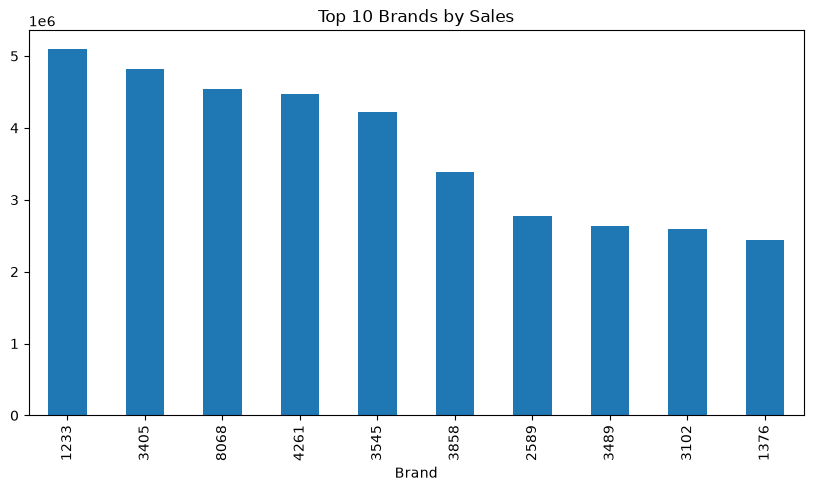

In [18]:
brand_sales.head(10).plot(kind="bar",figsize=(10,5),
title="Top 10 Brands by Sales")

In [21]:
purchases=pd.read_csv("purchases.csv")

In [22]:
purchases.shape

(2372474, 16)

In [24]:
purchases.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber',
       'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate',
       'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification'],
      dtype='str')

In [25]:
purchases.isnull().sum()

InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

In [26]:
vendor_invoice=pd.read_csv("vendor_invoice.csv")

In [27]:
vendor_invoice.shape

(5543, 10)

In [28]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='str')

In [30]:
vendor_invoice.isnull().sum()

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

In [33]:
purchases.columns.tolist()

['InventoryId',
 'Store',
 'Brand',
 'Description',
 'Size',
 'VendorNumber',
 'VendorName',
 'PONumber',
 'PODate',
 'ReceivingDate',
 'InvoiceDate',
 'PayDate',
 'PurchasePrice',
 'Quantity',
 'Dollars',
 'Classification']

In [3]:
import pandas as pd
purchases = pd.read_csv("purchases.csv")

In [4]:
purchases.shape

(2372474, 16)

## Vendor Performance Analysis

This section evaluates vendors based on purchasing value, sales performance, profitability, profit margin, and sales contribution.

In [7]:
Vendor_purchase = purchases.groupby(
    ["VendorNumber","VendorName"]
)["Dollars"].sum().sort_values(ascending=False) 

Vendor_purchase.head(10)

VendorNumber  VendorName                 
3960          DIAGEO NORTH AMERICA INC       50959796.85
4425          MARTIGNETTI COMPANIES          27821473.91
12546         JIM BEAM BRANDS COMPANY        24203151.05
17035         PERNOD RICARD USA              24124091.56
480           BACARDI USA INC                17624378.72
1392          CONSTELLATION BRANDS INC       15573917.90
1128          BROWN-FORMAN CORP              13529433.08
9165          ULTRA BEVERAGE COMPANY LLP     13210613.93
3252          E & J GALLO WINERY             12289608.09
9552          M S WALKER INC                 10935817.30
Name: Dollars, dtype: float64

<Axes: title={'center': 'Top 10 Vendors by Purchase Value'}, xlabel='VendorNumber,VendorName'>

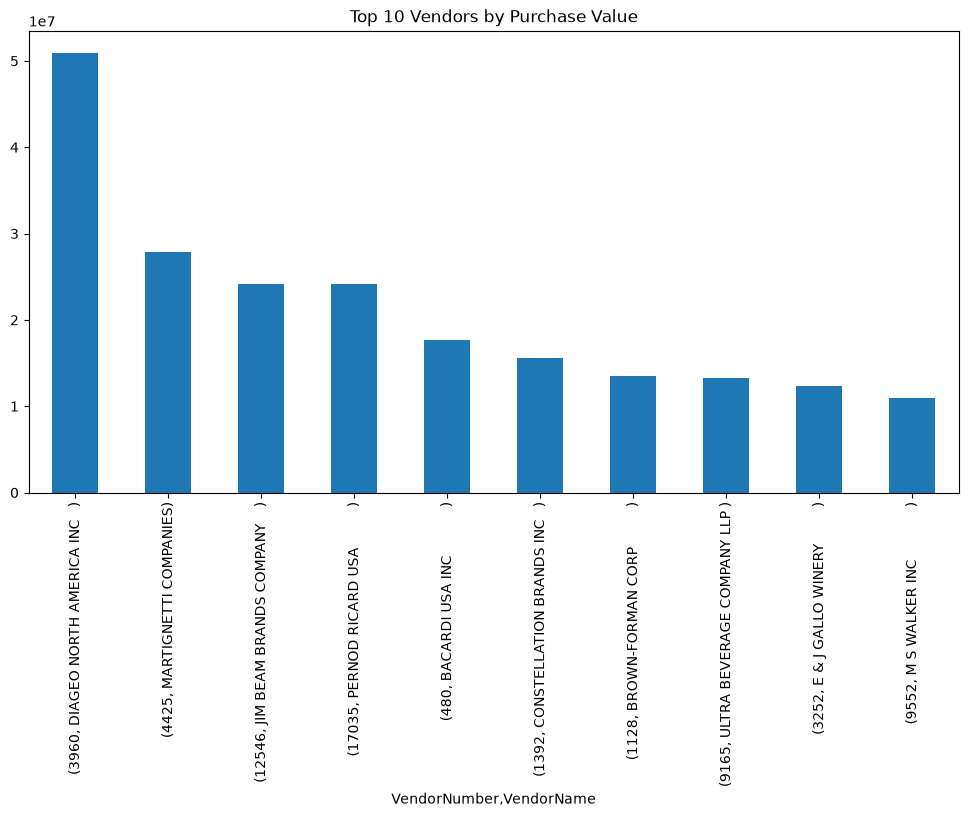

In [8]:
Vendor_purchase.head(10).plot(
    kind="bar",
    figsize=(12,6),
    title="Top 10 Vendors by Purchase Value"
)

In [12]:
sales = pd.read_csv("sales.csv")

In [13]:
sales.shape

(12825363, 14)

In [14]:
sales.columns.tolist()

['InventoryId',
 'Store',
 'Brand',
 'Description',
 'Size',
 'SalesQuantity',
 'SalesDollars',
 'SalesPrice',
 'SalesDate',
 'Volume',
 'Classification',
 'ExciseTax',
 'VendorNo',
 'VendorName']

In [20]:
vendor_sales = sales.groupby(
    ["VendorNo","VendorName"]
)["SalesDollars"].sum().sort_values(ascending=False)

vendor_sales.head(10)

VendorNo  VendorName                 
3960      DIAGEO NORTH AMERICA INC       68742416.99
4425      MARTIGNETTI COMPANIES          40992395.93
17035     PERNOD RICARD USA              32281247.95
12546     JIM BEAM BRANDS COMPANY        31906320.54
480       BACARDI USA INC                25014556.89
1392      CONSTELLATION BRANDS INC       24469172.93
3252      E & J GALLO WINERY             18556085.61
1128      BROWN-FORMAN CORP              18478557.47
9165      ULTRA BEVERAGE COMPANY LLP     17822938.45
9552      M S WALKER INC                 15465247.75
Name: SalesDollars, dtype: float64

In [26]:
vendor_performance = pd.merge(
    Vendor_purchase.reset_index(),
    vendor_sales.reset_index(),
    left_on=["VendorNumber", "VendorName"],
    right_on=["VendorNo","VendorName"],
    how="outer"
)

vendor_performance = vendor_performance.fillna(0)

vendor_performance = vendor_performance[
    ["VendorNumber", "VendorName", "Dollars", "SalesDollars"]
]

vendor_performance.columns = [
    "VendorNumber",
    "VendorName",
    "PurchaseDollars",
    "SalesDollars"
]

vendor_performance.head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58
1,54.0,AAPER ALCOHOL & CHEMICAL CO,105.07,0.00
2,60.0,ADAMBA IMPORTS INTL INC,76770.25,67576.22
3,105.0,ALTAMAR BRANDS LLC,11706.20,15748.75
4,200.0,AMERICAN SPIRITS EXCHANGE,1205.16,1719.97
5,287.0,APPOLO VINEYARDS LLC,2399.70,1616.92
6,388.0,ATLANTIC IMPORTING COMPANY,41116.32,59272.75
7,480.0,BACARDI USA INC,17624378.72,25014556.89
8,516.0,BANFI PRODUCTS CORP,1628866.68,2646325.62
9,653.0,STATE WINE & SPIRITS,1529682.04,2299075.40


In [27]:
vendor_performance["Profit"] = (
    vendor_performance["SalesDollars"]
    - vendor_performance["PurchaseDollars"]
)

vendor_performance["ProfitMargin"] = (
    vendor_performance["Profit"]
    / vendor_performance["SalesDollars"]
) * 100

vendor_performance.head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58,-4365.30,-344.924857
1,54.0,AAPER ALCOHOL & CHEMICAL CO,105.07,0.00,-105.07,-inf
2,60.0,ADAMBA IMPORTS INTL INC,76770.25,67576.22,-9194.03,-13.605422
3,105.0,ALTAMAR BRANDS LLC,11706.20,15748.75,4042.55,25.669021
4,200.0,AMERICAN SPIRITS EXCHANGE,1205.16,1719.97,514.81,29.931336
5,287.0,APPOLO VINEYARDS LLC,2399.70,1616.92,-782.78,-48.411795
6,388.0,ATLANTIC IMPORTING COMPANY,41116.32,59272.75,18156.43,30.632002
7,480.0,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
8,516.0,BANFI PRODUCTS CORP,1628866.68,2646325.62,1017458.94,38.447987
9,653.0,STATE WINE & SPIRITS,1529682.04,2299075.40,769393.36,33.465338


In [28]:
top_profitable_vendors = vendor_performance.sort_values(
    "Profit",
    ascending=False
)

top_profitable_vendors.head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
43,3960.0,DIAGEO NORTH AMERICA INC,50959796.85,68742416.99,17782620.14,25.868483
45,4425.0,MARTIGNETTI COMPANIES,27821473.91,40992395.93,13170922.02,32.130159
17,1392.0,CONSTELLATION BRANDS INC,15573917.90,24469172.93,8895255.03,36.352904
104,17035.0,PERNOD RICARD USA,24124091.56,32281247.95,8157156.39,25.269024
100,12546.0,JIM BEAM BRANDS COMPANY,24203151.05,31906320.54,7703169.49,24.143083
7,480.0,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
37,3252.0,E & J GALLO WINERY,12289608.09,18556085.61,6266477.52,33.770471
13,1128.0,BROWN-FORMAN CORP,13529433.08,18478557.47,4949124.39,26.783067
84,9165.0,ULTRA BEVERAGE COMPANY LLP,13210613.93,17822938.45,4612324.52,25.878586
87,9552.0,M S WALKER INC,10935817.30,15465247.75,4529430.45,29.287798


<Axes: title={'center': 'Top 10 Vendors by Profit'}, xlabel='VendorName'>

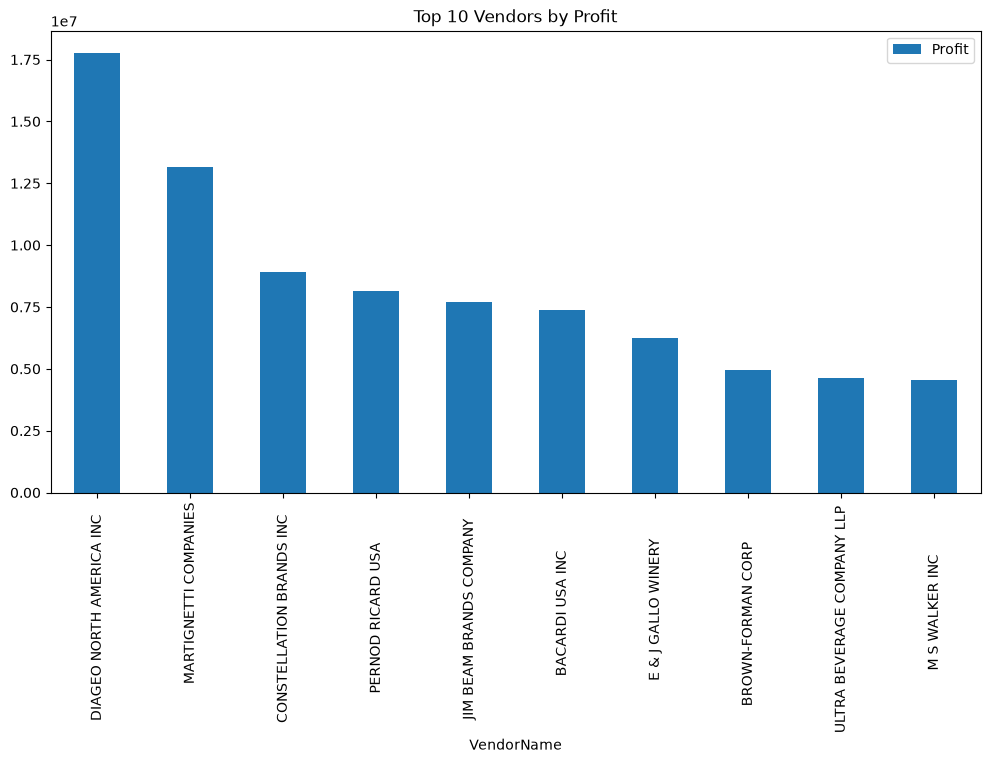

In [29]:
top_profitable_vendors.head(10).plot(
    x="VendorName",
    y="Profit",
    kind="bar",
    figsize=(12,6),
    title="Top 10 Vendors by Profit"
)

In [30]:
top_margin_vendors = vendor_performance[
    vendor_performance["SalesDollars"] > 0
].sort_values(
    "ProfitMargin",
    ascending=False
)

top_margin_vendors[
    ["VendorName", "PurchaseDollars", "SalesDollars", "Profit", "ProfitMargin"]
].head(10)

,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
90,WHYTE & MACKAY,0.00,31.98,31.98,100.000000
11,BERNIKO LLC,0.00,16.99,16.99,100.000000
116,EXCLUSIVE WINES & SPIRITS,0.00,55.98,55.98,100.000000
131,FLAVOR ESSENCE INC,17.00,1474.41,1457.41,98.846996
112,SILVER MOUNTAIN CIDERS,77.18,381.48,304.30,79.768271
18,CAPSTONE INTERNATIONAL,54.64,246.87,192.23,77.866894
26,ALISA CARR BEVERAGES,34951.68,118167.38,83215.70,70.421888
77,STAR INDUSTRIES INC.,2452.29,7914.72,5462.43,69.016086
117,THE PIERPONT GROUP LLC,5713.19,17937.21,12224.02,68.148948
71,R.P.IMPORTS INC,18776.87,54266.62,35489.75,65.398858


<Axes: title={'center': 'Top 10 Vendors by Profit Margin'}, xlabel='VendorName'>

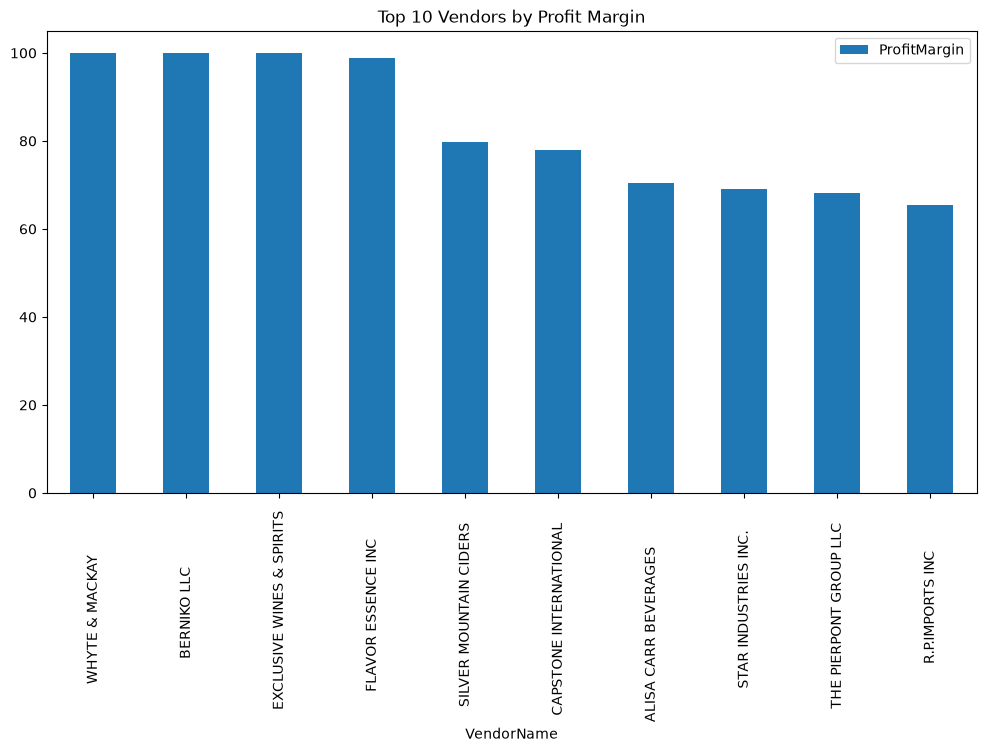

In [31]:
top_margin_vendors.head(10).plot(
    x="VendorName",
    y="ProfitMargin",
    kind="bar",
    figsize=(12,6),
    title="Top 10 Vendors by Profit Margin"
)

In [32]:
vendor_performance["SalesToPurchaseRatio"] = (
    vendor_performance["SalesDollars"]
    / vendor_performance["PurchaseDollars"]
)

vendor_performance[
    vendor_performance["PurchaseDollars"] > 0
].sort_values(
    "SalesToPurchaseRatio"
).head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin,SalesToPurchaseRatio
1,54.0,AAPER ALCOHOL & CHEMICAL CO,105.07,0.00,-105.07,-inf,0.000000
51,4901.0,LAUREATE IMPORTS CO,140.94,0.00,-140.94,-inf,0.000000
83,9099.0,TRUETT HURST,236.64,14.99,-221.65,-1478.652435,0.063345
0,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58,-4365.30,-344.924857,0.224757
42,3951.0,HIGHLAND WINE MERCHANTS LLC,5500.32,1533.68,-3966.64,-258.635439,0.278835
60,6280.0,UNCORKED,2966.31,1124.38,-1841.93,-163.817393,0.379050
21,1587.0,VINEYARD BRANDS LLC,10951.51,4323.96,-6627.55,-153.275007,0.394828
126,90059.0,BLACK COVE BEVERAGES,14465.06,6256.87,-8208.19,-131.186839,0.432551
53,5083.0,LOYAL DOG WINERY,2320.80,1111.26,-1209.54,-108.844015,0.478826
5,287.0,APPOLO VINEYARDS LLC,2399.70,1616.92,-782.78,-48.411795,0.673801


In [33]:
inventory_purchase = purchases.groupby(
    "InventoryId"
)["Quantity"].sum()

inventory_sales = sales.groupby(
    "InventoryId"
)["SalesQuantity"].sum()

inventory_performance = pd.concat(
    [inventory_purchase, inventory_sales],
    axis=1
)

inventory_performance.columns = [
    "PurchasedQuantity",
    "SoldQuantity"
]

inventory_performance = inventory_performance.fillna(0)

inventory_performance.head()

,PurchasedQuantity,SoldQuantity
InventoryId,,
10_HORNSEY_1001,120.0,131.0
10_HORNSEY_1003,227.0,154.0
10_HORNSEY_10030,13.0,13.0
10_HORNSEY_1004,12.0,12.0
10_HORNSEY_10057,12.0,12.0


In [34]:
inventory_performance["UnsoldQuantity"] = (
    inventory_performance["PurchasedQuantity"]
    - inventory_performance["SoldQuantity"]
)

inventory_performance.sort_values(
    "UnsoldQuantity",
    ascending=False
).head(10)

,PurchasedQuantity,SoldQuantity,UnsoldQuantity
InventoryId,,,
50_MOUNTMEND_5609,3816.0,140.0,3676.0
67_EANVERNESS_5111,7409.0,4568.0,2841.0
50_MOUNTMEND_5614,1920.0,142.0,1778.0
50_MOUNTMEND_5598,1896.0,207.0,1689.0
50_MOUNTMEND_754,1800.0,209.0,1591.0
50_MOUNTMEND_8500,1804.0,582.0,1222.0
50_MOUNTMEND_2277,1793.0,573.0,1220.0
61_AETHELNEY_3224,1080.0,78.0,1002.0
67_EANVERNESS_5609,960.0,28.0,932.0


In [35]:
total_vendor_sales = vendor_performance["SalesDollars"].sum()

vendor_performance["SalesContribution"] = (
    vendor_performance["SalesDollars"]
    / total_vendor_sales
) * 100

vendor_performance[
    ["VendorName", "SalesDollars", "SalesContribution"]
].sort_values(
    "SalesDollars",
    ascending=False
).head(10)

,VendorName,SalesDollars,SalesContribution
43,DIAGEO NORTH AMERICA INC,68742416.99,15.206381
45,MARTIGNETTI COMPANIES,40992395.93,9.067851
104,PERNOD RICARD USA,32281247.95,7.140874
100,JIM BEAM BRANDS COMPANY,31906320.54,7.057937
7,BACARDI USA INC,25014556.89,5.533423
17,CONSTELLATION BRANDS INC,24469172.93,5.412780
37,E & J GALLO WINERY,18556085.61,4.104757
13,BROWN-FORMAN CORP,18478557.47,4.087607
84,ULTRA BEVERAGE COMPANY LLP,17822938.45,3.942579
87,M S WALKER INC,15465247.75,3.421039


<Axes: title={'center': 'Top 10 Vendors by Sales Contribution'}, xlabel='VendorName'>

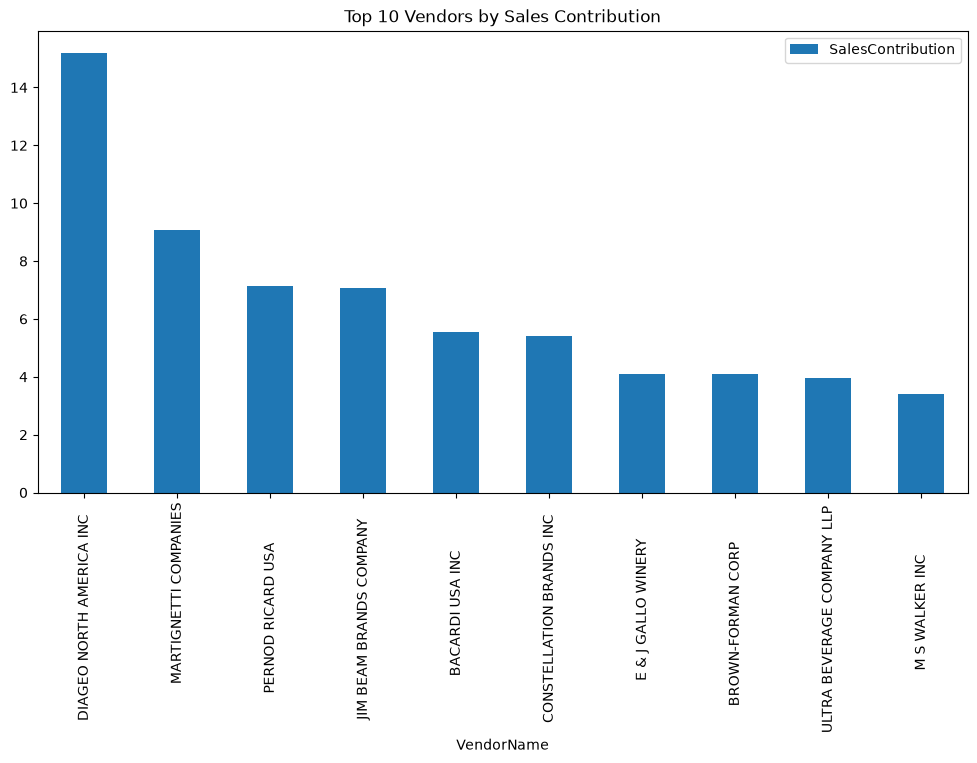

In [36]:
vendor_performance.sort_values(
    "SalesContribution",
    ascending=False
).head(10).plot(
    x="VendorName",
    y="SalesContribution",
    kind="bar",
    figsize=(12,6),
    title="Top 10 Vendors by Sales Contribution"
)

In [38]:
vendor_performance.shape

(132, 8)

In [39]:
vendor_performance["VendorNumber"].nunique()

127

In [41]:
vendor_performance["VendorName"].nunique()

132

In [43]:
vendor_performance[vendor_performance.duplicated("VendorNumber", keep=False)]

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin,SalesToPurchaseRatio,SalesContribution
11,0.0,BERNIKO LLC,0.00,16.99,16.99,100.000000,inf,0.000004
20,1587.0,VINEYARD BRANDS INC,1196162.81,1845237.53,649074.72,35.175673,1.542631,0.408182
21,1587.0,VINEYARD BRANDS LLC,10951.51,4323.96,-6627.55,-153.275007,0.394828,0.000956
27,2000.0,SOUTHERN GLAZERS W&S OF NE,40803.92,40440.12,-363.80,-0.899602,0.991084,0.008946
28,2000.0,SOUTHERN WINE & SPIRITS NE,3699813.46,5729494.21,2029680.75,35.425130,1.548590,1.267411
45,4425.0,MARTIGNETTI COMPANIES,27821473.91,40992395.93,13170922.02,32.130159,1.473408,9.067851
46,4425.0,MARTIGNETTI COMPANIES,40216.11,54910.37,14694.26,26.760446,1.365382,0.012147
90,0.0,WHYTE & MACKAY,0.00,31.98,31.98,100.000000,inf,0.000007
116,0.0,EXCLUSIVE WINES & SPIRITS,0.00,55.98,55.98,100.000000,inf,0.000012


In [44]:
vendor_performance[
    vendor_performance.duplicated("VendorNumber", keep=False)
][["VendorNumber", "VendorName"]]

,VendorNumber,VendorName
11,0.0,BERNIKO LLC
20,1587.0,VINEYARD BRANDS INC
21,1587.0,VINEYARD BRANDS LLC
27,2000.0,SOUTHERN GLAZERS W&S OF NE
28,2000.0,SOUTHERN WINE & SPIRITS NE
45,4425.0,MARTIGNETTI COMPANIES
46,4425.0,MARTIGNETTI COMPANIES
90,0.0,WHYTE & MACKAY
116,0.0,EXCLUSIVE WINES & SPIRITS


In [45]:
vendor_final = vendor_performance.groupby(
    "VendorNumber",
    as_index=False
).agg({
    "VendorName": "first",
    "PurchaseDollars": "sum",
    "SalesDollars": "sum",
    "Profit": "sum"
})

vendor_final["ProfitMargin"] = (
    vendor_final["Profit"] / vendor_final["SalesDollars"]
) * 100

vendor_final.head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
0,0.0,BERNIKO LLC,0.00,104.95,104.95,100.000000
1,2.0,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58,-4365.30,-344.924857
2,54.0,AAPER ALCOHOL & CHEMICAL CO,105.07,0.00,-105.07,-inf
3,60.0,ADAMBA IMPORTS INTL INC,76770.25,67576.22,-9194.03,-13.605422
4,105.0,ALTAMAR BRANDS LLC,11706.20,15748.75,4042.55,25.669021
5,200.0,AMERICAN SPIRITS EXCHANGE,1205.16,1719.97,514.81,29.931336
6,287.0,APPOLO VINEYARDS LLC,2399.70,1616.92,-782.78,-48.411795
7,388.0,ATLANTIC IMPORTING COMPANY,41116.32,59272.75,18156.43,30.632002
8,480.0,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
9,516.0,BANFI PRODUCTS CORP,1628866.68,2646325.62,1017458.94,38.447987


In [46]:
vendor_final.shape

(127, 6)

In [47]:
vendor_final.sort_values(
    "SalesDollars",
    ascending=False
)[[
    "VendorNumber",
    "VendorName",
    "PurchaseDollars",
    "SalesDollars",
    "Profit",
    "ProfitMargin"
]].head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
41,3960.0,DIAGEO NORTH AMERICA INC,50959796.85,68742416.99,17782620.14,25.868483
43,4425.0,MARTIGNETTI COMPANIES,27861690.02,41047306.30,13185616.28,32.122976
100,17035.0,PERNOD RICARD USA,24124091.56,32281247.95,8157156.39,25.269024
96,12546.0,JIM BEAM BRANDS COMPANY,24203151.05,31906320.54,7703169.49,24.143083
8,480.0,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
17,1392.0,CONSTELLATION BRANDS INC,15573917.90,24469172.93,8895255.03,36.352904
35,3252.0,E & J GALLO WINERY,12289608.09,18556085.61,6266477.52,33.770471
13,1128.0,BROWN-FORMAN CORP,13529433.08,18478557.47,4949124.39,26.783067
81,9165.0,ULTRA BEVERAGE COMPANY LLP,13210613.93,17822938.45,4612324.52,25.878586
84,9552.0,M S WALKER INC,10935817.30,15465247.75,4529430.45,29.287798


In [48]:
vendor_final.sort_values(
    "Profit",
    ascending=False
)[[
    "VendorNumber",
    "VendorName",
    "PurchaseDollars",
    "SalesDollars",
    "Profit",
    "ProfitMargin"
]].head(10)

,VendorNumber,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
41,3960.0,DIAGEO NORTH AMERICA INC,50959796.85,68742416.99,17782620.14,25.868483
43,4425.0,MARTIGNETTI COMPANIES,27861690.02,41047306.30,13185616.28,32.122976
17,1392.0,CONSTELLATION BRANDS INC,15573917.90,24469172.93,8895255.03,36.352904
100,17035.0,PERNOD RICARD USA,24124091.56,32281247.95,8157156.39,25.269024
96,12546.0,JIM BEAM BRANDS COMPANY,24203151.05,31906320.54,7703169.49,24.143083
8,480.0,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
35,3252.0,E & J GALLO WINERY,12289608.09,18556085.61,6266477.52,33.770471
13,1128.0,BROWN-FORMAN CORP,13529433.08,18478557.47,4949124.39,26.783067
81,9165.0,ULTRA BEVERAGE COMPANY LLP,13210613.93,17822938.45,4612324.52,25.878586
84,9552.0,M S WALKER INC,10935817.30,15465247.75,4529430.45,29.287798


<Axes: title={'center': 'Top 10 Vendors by Profit'}, xlabel='VendorName'>

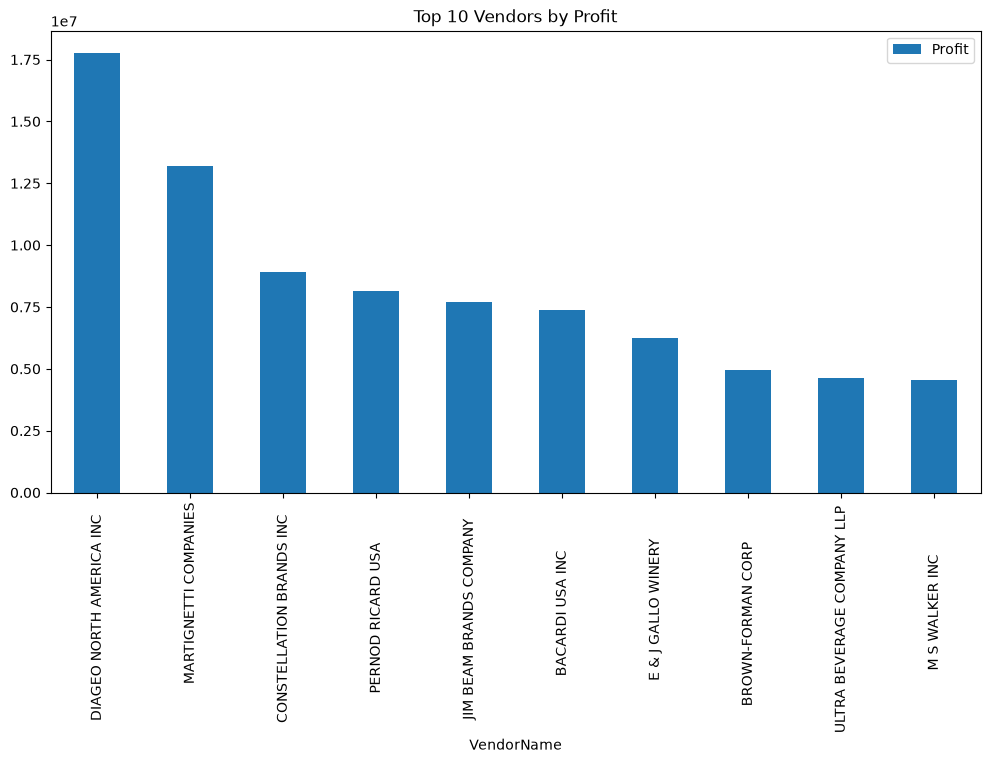

In [49]:
top_profit = vendor_final.sort_values(
    "Profit",
    ascending=False
).head(10)

top_profit.plot(
    x="VendorName",
    y="Profit",
    kind="bar",
    figsize=(12, 6),
    title="Top 10 Vendors by Profit"
)

In [51]:
total_purchase = vendor_final["PurchaseDollars"].sum()
total_sales = vendor_final["SalesDollars"].sum()
total_profit = vendor_final["Profit"].sum()
overall_margin = (total_profit / total_sales) * 100

print("Total Vendors:", vendor_final["VendorNumber"].nunique())
print("Total Purchase Value: $", round(total_purchase, 2))
print("Total Sales Value: $", round(total_sales, 2))
print("Total Profit: $", round(total_profit, 2))
print("Overall Profit Margin: ", round(overall_margin, 2), "%")

Total Vendors: 127
Total Purchase Value: $ 321900765.53
Total Sales Value: $ 452062952.02
Total Profit: $ 130162186.49
Overall Profit Margin:  28.79 %


In [53]:
print("Vendors:", vendor_final["VendorNumber"].nunique())

Vendors: 127


In [54]:
print("Total Purchase: $", round(vendor_final["PurchaseDollars"].sum(), 2))

Total Purchase: $ 321900765.53


In [55]:
print("Total Sales: $", round(vendor_final["SalesDollars"].sum(), 2))

Total Sales: $ 452062952.02


In [56]:
print("Total Profit: $", round(vendor_final["Profit"].sum(), 2))

Total Profit: $ 130162186.49


In [57]:
print("Profit Margin: ", round((vendor_final["Profit"].sum() / vendor_final["SalesDollars"].sum()) * 100, 2), "%")

Profit Margin:  28.79 %


In [58]:
print("===== VENDOR PERFORMANCE SUMMARY =====")
print("Total Vendors:", vendor_final["VendorNumber"].nunique())
print("Total Purchase Value: $", round(vendor_final["PurchaseDollars"].sum(), 2))
print("Total Sales Value: $", round(vendor_final["SalesDollars"].sum(), 2))
print("Total Profit: $", round(vendor_final["Profit"].sum(), 2))
print("Overall Profit Margin: ", round(
    (vendor_final["Profit"].sum() / vendor_final["SalesDollars"].sum()) * 100, 2
), "%")

===== VENDOR PERFORMANCE SUMMARY =====
Total Vendors: 127
Total Purchase Value: $ 321900765.53
Total Sales Value: $ 452062952.02
Total Profit: $ 130162186.49
Overall Profit Margin:  28.79 %


## Key business Insight 

In [59]:
top_sales_vendor = vendor_final.loc[vendor_final["SalesDollars"].idxmax()]

top_profit_vendor = vendor_final.loc[vendor_final["Profit"].idxmax()]

print("Top Vendor by Sales:")
print(top_sales_vendor[["VendorName", "SalesDollars"]])

print("\nTop Vendor by Profit:")
print(top_profit_vendor[["VendorName", "Profit"]])

print("\nHighest Profit Margin:")
print(
    vendor_final.loc[
        vendor_final["ProfitMargin"].idxmax(),
        ["VendorName", "ProfitMargin"]
    ]
)

Top Vendor by Sales:
VendorName      DIAGEO NORTH AMERICA INC   
SalesDollars                    68742416.99
Name: 41, dtype: object

Top Vendor by Profit:
VendorName    DIAGEO NORTH AMERICA INC   
Profit                        17782620.14
Name: 41, dtype: object

Highest Profit Margin:
VendorName      BERNIKO LLC                
ProfitMargin                          100.0
Name: 0, dtype: object


In [60]:
import sqlite3

conn = sqlite3.connect("vendor_analysis.db")

vendor_final.to_sql(
    "vendor_performance",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [61]:
query = """
SELECT VendorName,
       SalesDollars,
       Profit,
       ProfitMargin
FROM vendor_performance
ORDER BY SalesDollars DESC
LIMIT 10;
"""

top_10_sql = pd.read_sql_query(query, conn)

top_10_sql

,VendorName,SalesDollars,Profit,ProfitMargin
0,DIAGEO NORTH AMERICA INC,68742416.99,17782620.14,25.868483
1,MARTIGNETTI COMPANIES,41047306.30,13185616.28,32.122976
2,PERNOD RICARD USA,32281247.95,8157156.39,25.269024
3,JIM BEAM BRANDS COMPANY,31906320.54,7703169.49,24.143083
4,BACARDI USA INC,25014556.89,7390178.17,29.543510
5,CONSTELLATION BRANDS INC,24469172.93,8895255.03,36.352904
6,E & J GALLO WINERY,18556085.61,6266477.52,33.770471
7,BROWN-FORMAN CORP,18478557.47,4949124.39,26.783067
8,ULTRA BEVERAGE COMPANY LLP,17822938.45,4612324.52,25.878586
9,M S WALKER INC,15465247.75,4529430.45,29.287798


In [62]:
query = """
SELECT VendorName,
       PurchaseDollars,
       SalesDollars,
       Profit,
       ProfitMargin
FROM vendor_performance
ORDER BY Profit DESC
LIMIT 10;
"""

top_profit_sql = pd.read_sql_query(query, conn)

top_profit_sql

,VendorName,PurchaseDollars,SalesDollars,Profit,ProfitMargin
0,DIAGEO NORTH AMERICA INC,50959796.85,68742416.99,17782620.14,25.868483
1,MARTIGNETTI COMPANIES,27861690.02,41047306.30,13185616.28,32.122976
2,CONSTELLATION BRANDS INC,15573917.90,24469172.93,8895255.03,36.352904
3,PERNOD RICARD USA,24124091.56,32281247.95,8157156.39,25.269024
4,JIM BEAM BRANDS COMPANY,24203151.05,31906320.54,7703169.49,24.143083
5,BACARDI USA INC,17624378.72,25014556.89,7390178.17,29.543510
6,E & J GALLO WINERY,12289608.09,18556085.61,6266477.52,33.770471
7,BROWN-FORMAN CORP,13529433.08,18478557.47,4949124.39,26.783067
8,ULTRA BEVERAGE COMPANY LLP,13210613.93,17822938.45,4612324.52,25.878586
9,M S WALKER INC,10935817.30,15465247.75,4529430.45,29.287798


In [63]:
query = """
SELECT VendorName,
       SalesDollars,
       Profit,
       ProfitMargin
FROM vendor_performance
WHERE SalesDollars > 0
ORDER BY ProfitMargin DESC
LIMIT 10;
"""

top_margin_sql = pd.read_sql_query(query, conn)

top_margin_sql

,VendorName,SalesDollars,Profit,ProfitMargin
0,BERNIKO LLC,104.95,104.95,100.000000
1,FLAVOR ESSENCE INC,1474.41,1457.41,98.846996
2,SILVER MOUNTAIN CIDERS,381.48,304.30,79.768271
3,CAPSTONE INTERNATIONAL,246.87,192.23,77.866894
4,ALISA CARR BEVERAGES,118167.38,83215.70,70.421888
5,STAR INDUSTRIES INC.,7914.72,5462.43,69.016086
6,THE PIERPONT GROUP LLC,17937.21,12224.02,68.148948
7,R.P.IMPORTS INC,54266.62,35489.75,65.398858
8,FANTASY FINE WINES CORP,327.59,198.95,60.731402
9,VINEDREA WINES LLC,11385.60,6728.00,59.092187


## Conclusion

This analysis evaluated vendor performance using purchasing value, sales value, profit, profit margin, and sales contribution. SQL queries were also used to analyze vendor-level performance and validate key results.

The analysis provides a data-driven view of vendor profitability and purchasing performance that can support better business and inventory decisions.